# Graded Lab: Structured Output and Retrieval-Augmented Generation (RAG)

Welcome to the first assignment of this course! 

Carefully read each Markdown (text) cell, which include instructions and hints. Start by reading the background behind your upcoming tasks.

When you are done, submit your solution by saving it, then clicking on the submit button at the top right side of the page.

## In order for your submission to be graded correctly, you **MUST**:
* **Use the provided variable names**, otherwise the autograder will not be able to locate the variable for grading. 

* **Replace any instances of `None` with your own code.** 

* **Only modify the cells that start with the comment `# GRADED CELL`**.  

* **Use the provided cells for your solution.** You can add new cells to experiment, but these will be omitted when grading. 

To submit your solution, save it, then click on the blue submit button at the top of the page.

<div style="background-color: #FAD888; padding: 10px; border-radius: 3px; box-shadow: 0 2px 4px rgba(0, 0, 0, 0.1); width:95%
">
<strong>Important notes</strong>:

- Code blocks with None will not run properly. If you run them before completing the exercise, you will likely get an error. 

- The notebooks work best in Chrome browser. If you are having problems, please switch to Chrome.

- Make sure you always save before submitting.
</div>

## Introduction

When you use an LLM in a real application, you often need two things: **structured output** (so downstream code can parse the response reliably) and **grounded answers** (so the model responds based on real documents rather than guessing). This lab explores both.

In **Part 1 (Structured Output)**, you'll compare two strategies for getting an LLM to produce valid JSON that conforms to a specific schema using a real dataset of messy GitHub issues as input. You'll see firsthand how prompt-only ("soft") constraints can fail, and how **constrained decoding** guarantees valid output by intervening at the token level.

In **Part 2 (RAG)**, you'll build a Retrieval-Augmented Generation pipeline from scratch. You will chunk real PyTorch documentation, retrieve relevant passages, and generate grounded answers. You'll then stress-test the pipeline to understand when too little or too much context hurts answer quality.

## Objectives

By the end of this lab, you will:

- **Write a Structured Output Prompt**: Craft a prompt that instructs an LLM to return valid JSON matching a defined Pydantic schema, and evaluate its reliability across multiple runs.
- **Implement Constrained Decoding**: Use the `outlines` library to enforce schema-valid output at the token level, guaranteeing 100% compliance.
- **Chunk Documents for Retrieval**: Split long documents into right-sized chunks that respect paragraph boundaries for effective semantic search.
- **Build a RAG Pipeline**: Assemble retrieval, context packing, prompt construction, and generation into an end-to-end grounded question-answering system.
- **Stress-Test RAG Under Different Context Budgets**: Compare tight, normal, and flooded context conditions to understand when extra context helps vs. hurts.

## Table of Contents

**Part 1: Structured Output**
- Imports and Device Check
- Load Model
- Generate Helper
- Define the Target Schema
- Load GitHub Issues Dataset
- JSON Parsing: Strict vs. Lenient
- Strategy 1: Soft Constraints (Prompt-Only) — Exercise 1
- Strategy 2: Constrained Decoding — Exercise 2
- Visualizing Constrained Decoding

**Part 2: Retrieval-Augmented Generation (RAG)**
- Setup
- Fetch and Explore the Corpus
- Chunk Documents for Retrieval — Exercise 3
- Build the RAG Pipeline — Exercise 4
- Stress-Test Your Pipeline — Exercise 5

## Part 1: Structured Output

### Background

Many real-world applications require LLM output to be machine-readable. Thhis is achieved by passing a JSON object with specific fields and valid values, rather than free-form text. For example, an automated triage system for GitHub issues needs structured fields like `issue_type`, `severity`, and `affected_components` to route issues to the right team.

There are two broad strategies for achieving this:

| Strategy | How It Works | Guarantee |
|----------|-------------|-----------|
| **Soft Constraints** | The prompt asks the model to produce valid JSON | No guarantee — the model may add markdown fences, use invalid values, or produce malformed JSON |
| **Constrained Decoding** | A finite state machine masks invalid tokens at every generation step| 100% schema compliance — invalid tokens are impossible |

You'll implement and compare both strategies on the same dataset and schema, so you can see exactly where prompt-only approaches fail and why constrained decoding matters for production systems.

### Imports and Device Check

Standard setup. Checks whether a GPU is available. The model runs on GPU if present, CPU otherwise. The `utils` module provides helper functions for generation, JSON parsing, document fetching, and retrieval that you'll use throughout this lab.

In [1]:
import warnings, logging, os
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

In [2]:
import time
from typing import List, Dict, Any, Optional, Literal
import torch
import outlines
from pydantic import BaseModel, Field
from transformers import AutoTokenizer, AutoModelForCausalLM

from utils import generate, try_parse_strict, try_parse_lenient

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: AMD Instinct MI300X VF


### Load Model

You'll use Qwen 2.5 1.5B Instruct throughout this lab. The 1.5B size is deliberate: a smaller model is worse at following format instructions from prompts alone, which makes soft constraint failures more visible and the value of constrained decoding clearer.

- `torch_dtype=torch.float16` uses half-precision to save GPU memory.
- `device_map="auto"` places the model on available GPUs automatically.

In [3]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.float16, device_map="auto"
)
print("Model loaded.")

Model loaded.


### Generate Helper

The `generate` function from `utils.py` is a wrapper that takes a prompt (either a plain string or a chat-style message list like `[{"role": "user", "content": "..."}]`), applies the model's chat template, runs generation, and returns only the newly generated text (stripping the prompt). Key parameters:

- `temperature=0.0` → greedy decoding. Deterministic. **(default)**
- `temperature > 0` → sampling enabled. Higher = more random = more variation between runs.
- `max_tokens` → hard cap on output length.

Try it out below to verify the model is working:

In [4]:
# Quick test — verify the model generates a response
test_response = generate(
    [{"role": "user", "content": "What is 2 + 2?"}],
    model, tokenizer, max_tokens=50
)
print(f"Test response: {test_response}")

Test response: The answer to 2 + 2 is 4.


### Define the Target Schema

This is the Pydantic schema — the exact JSON structure you want the model to produce. It defines:

- `issue_type` must be one of exactly 4 strings (not "bug_report", not "enhancement", not "error")
- `severity` must be one of exactly 4 strings (not "moderate", not "urgent")
- `affected_components` is a list of strings (flexible)
- `has_reproduction_steps` must be a boolean (not "yes", not "true" as a string)
- `environment` is a nested object with optional fields

This same schema is used across both strategies. The difference is *how* each strategy enforces it.

In [5]:
class IssueEnvironment(BaseModel):
    python_version: Optional[str] = None
    pytorch_version: Optional[str] = None
    rocm_version: Optional[str] = None
    os: Optional[str] = None

class ParsedIssue(BaseModel):
    issue_type: Literal["bug", "feature_request", "documentation", "question"]
    severity: Literal["critical", "high", "medium", "low"]
    affected_components: List[str]
    has_reproduction_steps: bool
    environment: IssueEnvironment

### Load GitHub Issues Dataset

You'll test both strategies on real, messy data rather than on clean synthetic examples. The dataset below contains ~3000 real GitHub issues from the HuggingFace `datasets` repository. You'll filter to issues with non-empty body text, then randomly sample 50.

These are real-world issues: bug reports with stack traces, feature requests, questions, issues with code blocks. They are much harder for an LLM to parse cleanly than synthetic examples, which is the point of this exercise. You want to see where each strategy breaks down.

In [6]:
from datasets import load_dataset
from utils import display_issues_preview

# lewtun/github-issues has actual issue body text (from HuggingFace datasets repo)
ds = load_dataset("lewtun/github-issues", split="train")
print(f"Total issues: {len(ds)}")
print(f"Columns: {ds.column_names}")

# Filter to issues that have a non-empty body, then sample
ds_with_body = ds.filter(lambda x: x["body"] is not None and len(x["body"].strip()) > 0)
print(f"Issues with body text: {len(ds_with_body)}")

sampled = ds_with_body.shuffle(seed=42).select(range(min(50, len(ds_with_body))))
issues = [{"title": item["title"], "body": item["body"]} for item in sampled]
print(f"Sampled {len(issues)} issues for parsing.")

# Preview a few
display_issues_preview(issues, n=5)

Using the latest cached version of the dataset since lewtun/github-issues couldn't be found on the Hugging Face Hub (offline mode is enabled).
Found the latest cached dataset configuration 'default' at /app/hf_cache/datasets/lewtun___github-issues/default/0.0.0/3bb24dcad2b45b45e20fc0accc93058dcbe8087d (last modified on Tue Aug 18 10:27:21 2026).


Total issues: 3019
Columns: ['url', 'repository_url', 'labels_url', 'comments_url', 'events_url', 'html_url', 'id', 'node_id', 'number', 'title', 'user', 'labels', 'state', 'locked', 'assignee', 'assignees', 'milestone', 'comments', 'created_at', 'updated_at', 'closed_at', 'author_association', 'active_lock_reason', 'pull_request', 'body', 'timeline_url', 'performed_via_github_app', 'is_pull_request']
Issues with body text: 2745
Sampled 50 issues for parsing.


#,Title,Body Preview
0,add dream dataset,Adding Dream: a Dataset and for Dialogue-Based Reading Comprehension More details: https://dataset.org/dream/ https://github.com/nlpdata/dream...
1,concatenate_datasets loads all the data into memory,"## Describe the bug When I try to concatenate 2 datasets (10GB each) , the entire data is loaded into memory instead of being written directly to disk..."
2,"load_metric from local ""glue.py"" meet error 'NoneType' object is not c","actual_task = ""mnli"" if task == ""mnli-mm"" else task dataset = load_dataset(path='/home/glue.py', name=actual_task) metric = load_metric(path='/home/gl..."
3,Implement Dataset to JSON,Implement `Dataset.to_json`....
4,How to choose proper download_mode in function load_dataset?,"Hi, I am a beginner to datasets and I try to use datasets to load my csv file. my csv file looks like this ``` text,label ""Effective but too-tepid bio..."


### JSON Parsing: Strict vs. Lenient

Before testing the strategies, you need a way to check whether model output is valid JSON. The `utils` module provides two parsers with different levels of tolerance:

- **`try_parse_strict`**: Passes the raw model output directly to `json.loads()`. If the model wrapped output in `` ```json ... ``` `` or added any preamble like "Here's the JSON:", this fails. This is what you'd need in a production pipeline where the output goes directly to another system.
- **`try_parse_lenient`**: Strips common LLM output quirks (markdown code fences) before parsing. More forgiving, but still fails if the JSON itself is structurally invalid.

You'll use **strict parsing as the default** throughout this lab to expose real failures. This mirrors what a production system would require.

In [7]:
# We'll use strict parsing to expose real failures
try_parse = try_parse_strict

### Strategy 1: Soft Constraints (Prompt-Only)

In this strategy, you rely entirely on the *prompt* to instruct the model to produce valid JSON. There are no programmatic guardrails. If the model decides to wrap its output in markdown fences, add a preamble, or use `"severity": "moderate"` instead of `"medium"`, nothing stops it.

#### Exercise 1: Write a Soft Constraint Prompt

Your task is to write a prompt string that instructs the model to return valid JSON matching the `ParsedIssue` schema. The prompt should:

1. Specify every field name and its allowed values
2. Explicitly tell the model to return *only* valid JSON, no markdown, no explanation
3. Include a placeholder `{issue_text}` for the actual issue content

After defining the prompt, run the evaluation cell below to test it against 10 issues, 3 times each (with `temperature=1.0` to introduce randomness), and see the strict/lenient/schema pass rates.


In [8]:
# GRADED CELL: exercise 1

### START CODE HERE ###
SOFT_PROMPT = """
Parse the issue below and return ONLY valid JSON matching the ParsedIssue schema.
Do not return markdown, code fences, explanations, commentary, or any text outside
the JSON object.

The JSON must contain exactly these fields:

- "issue_type": one of "bug", "feature_request", "documentation", "question"
- "severity": one of "critical", "high", "medium", "low"
- "affected_components": a JSON array of strings
- "has_reproduction_steps": a JSON boolean (true or false)
- "environment": a JSON object containing these optional fields:
  - "python_version": a string or null
  - "pytorch_version": a string or null
  - "rocm_version": a string or null
  - "os": a string or null

Return only the JSON object. Do not use markdown fences.

Issue:
{issue_text}
"""
### END CODE HERE ###

Run the evaluation below to see how your prompt performs:

In [9]:
from utils import make_results_table, print_failure

N_TEST = 10

# --- Run evaluation ---
soft_results = []
results_by_issue = []
failure_log = []

for i, issue in enumerate(issues[:N_TEST]):
    issue_text = f"Title: {issue['title']}\nBody: {issue['body'][:800]}"
    issue_runs = []

    for run in range(3):
        raw = generate(
            [{"role": "user", "content": SOFT_PROMPT.format(issue_text=issue_text)}],
            model, tokenizer,
            max_tokens=400, temperature=1.0
        )
        strict_ok = try_parse_strict(raw) is not None
        lenient_ok = try_parse_lenient(raw) is not None
        schema_ok = False
        parsed = try_parse_strict(raw)
        if parsed:
            try:
                ParsedIssue(**parsed)
                schema_ok = True
            except Exception:
                pass

        issue_runs.append({"strict_json": strict_ok, "lenient_json": lenient_ok, "schema_ok": schema_ok, "raw": raw})
        soft_results.append(issue_runs[-1])

        if not strict_ok or not schema_ok:
            tags = []
            if not strict_ok: tags.append("strict fail")
            if not schema_ok: tags.append("schema fail")
            failure_log.append((i, run, tags, raw))

    results_by_issue.append(issue_runs)

# --- Table ---
display(make_results_table(results_by_issue, issues, n_test=N_TEST))

# --- Failure details ---
if failure_log:
    print("\n--- Failure Details ---")
    for issue_i, run_i, tags, raw in failure_log:
        print_failure(issue_i, run_i, tags, raw)

# --- Summary ---
fence_failures = sum(1 for r in soft_results if not r["strict_json"] and r["raw"].strip().startswith("```"))
total_strict_failures = sum(1 for r in soft_results if not r["strict_json"])

print(f"\nStrict JSON: {sum(r['strict_json'] for r in soft_results)/len(soft_results):.0%} | "
      f"Lenient JSON: {sum(r['lenient_json'] for r in soft_results)/len(soft_results):.0%} | "
      f"Schema: {sum(r['schema_ok'] for r in soft_results)/len(soft_results):.0%}")
if total_strict_failures:
    print(f"Strict failures caused by markdown fences: {fence_failures}/{total_strict_failures} ({fence_failures/total_strict_failures:.0%})")

#,Issue,Strict,Lenient,Schema
0,add dream dataset,1/3,3/3,1/3
1,concatenate_datasets loads all the data into,3/3,3/3,3/3
2,"load_metric from local ""glue.py"" meet error '",0/3,3/3,0/3
3,Implement Dataset to JSON,1/3,3/3,1/3
4,How to choose proper download_mode in functio,1/3,3/3,1/3
5,Add Shrinked Turkish NER from Kaggle.,1/3,3/3,1/3
6,Add interleave_datasets for map-style dataset,0/3,3/3,0/3
7,Requirements should specify pyarrow<1,1/3,3/3,1/3
8,Add SLR70 - SLR80 and SLR86 to OpenSLR datase,0/3,3/3,0/3
9,Update dataset_info from gcs,2/3,3/3,2/3



--- Failure Details ---
Issue 0 Run 0 (strict fail, schema fail):
{
  "issue_type": "feature_request",
  "severity": "medium",
  "affected_components": [
    "Dataset",
    "Dialogue-Based Reading Comprehension"
  ],
  "has_reproduction_steps": true,
  "environment": {
    "python_version": null,
    "pytorch_version": null,
    "rocm_version": null,
    "os": null
  }
}
--------------------------------------------------
Issue 0 Run 1 (strict fail, schema fail):
{
  "issue_type": "feature_request",
  "severity": "medium",
  "affected_components": [
    "Dataset"
  ],
  "has_reproduction_steps": true,
  "environment": {
    "python_version": null,
    "pytorch_version": null,
    "rocm_version": null,
    "os": null
  }
}
--------------------------------------------------
Issue 2 Run 0 (strict fail, schema fail):
{
  "issue_type": "bug",
  "severity": "high",
  "affected_components": [
    "load_metric",
    "datasets.load",
    "path /home/glue.py"
  ],
  "has_reproduction_steps": tru

### Strategy 2: Constrained Decoding

This is the key insight of this lab. Instead of *asking* the model to produce valid JSON and hoping for the best, you **intervene at every generation step**:

1. The model produces logit scores for all ~150K tokens in its vocabulary
2. A finite state machine (FSM) compiled from your Pydantic schema determines which tokens are valid at the current position
3. All invalid tokens get their logits set to `-inf` (impossible to select)
4. The model samples from the remaining valid tokens

For example: when filling in `"issue_type": "???"`, only tokens that start spelling `bug`, `feature_request`, `documentation`, or `question` are allowed. The model literally *cannot* produce `"error"` or `"bug_report"`.

#### Exercise 2: Create a Constrained Generator

Your task is to use the `outlines` library to create a constrained generator that enforces the `ParsedIssue` schema. You need to:

1. Wrap the existing HuggingFace `model` and `tokenizer` with `outlines.Transformers(model, tokenizer)`.
2. Build the JSON-constrained callable with `outlines.Generator(outlines_model, outlines.types.json_schema(ParsedIssue))`.

Outlines uses your Pydantic schema so that only tokens keeping the output valid are allowed at each generation step (initial setup may take a moment).

In [10]:
# GRADED CELL: exercise 2

### START CODE HERE ###
outlines_model = outlines.Transformers(model, tokenizer)
constrained_gen = outlines.Generator(outlines_model, outlines.types.json_schema(ParsedIssue))
### END CODE HERE ###

print("Constrained generator ready.")

Constrained generator ready.


Run the evaluation below to compare with Strategy 1. Notice the success rate: constrained decoding produces schema-valid JSON far more reliably than the prompt-only approach.

**Why does a row still occasionally fail?** Constrained decoding guarantees that whatever the model emits *conforms to the schema* — but it does **not** guarantee the model *finishes*. Our schema has unbounded fields (`affected_components: List[str]` and the free-text `environment` strings). A string with no maximum length means "any character is valid here," so if a small model falls into a **repetition loop** (e.g. emitting `Linux/Windows/MacOSX/Linux/...` over and over), the finite state machine happily lets it continue. It never closes the string, eventually hits `max_new_tokens`, and the output is cut off mid-value — leaving JSON that ends inside an open string (the `EOF while parsing a string` error).

The takeaway: constrained decoding controls *structure*, not *termination* or *content quality*. In production you'd bound the schema fields (e.g. a `max_length` on strings and lists) or add a repetition penalty so generation is guaranteed to stop. We leave it unbounded here so you can observe this failure mode firsthand.

In [11]:
from utils import make_cd_results_table

cd_results = []
for i, issue in enumerate(issues[:N_TEST]):
    issue_text = f"Title: {issue['title']}\nBody: {issue['body'][:800]}"
    prompt = f"Parse this GitHub issue as JSON.\n\nIssue:\n{issue_text}\n\nJSON:"
    formatted = tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt}], tokenize=False, add_generation_prompt=True
    )
    t0 = time.time()
    raw = constrained_gen(formatted, max_new_tokens=1024)
    elapsed = time.time() - t0
    try:
        result = ParsedIssue.model_validate_json(raw)
        cd_results.append({"success": True, "time": elapsed, "issue_type": result.issue_type, "severity": result.severity})
    except Exception as e:
        cd_results.append({"success": False, "time": elapsed, "issue_type": "—", "severity": "—"})

display(make_cd_results_table(cd_results, issues, n_test=N_TEST))

#,Issue,Status,Type,Severity,Time
0,add dream dataset,✅ pass,bug,low,2.4s
1,concatenate_datasets loads all the data into,✅ pass,bug,critical,0.7s
2,"load_metric from local ""glue.py"" meet error '",✅ pass,bug,high,0.8s
3,Implement Dataset to JSON,✅ pass,bug,low,1.3s
4,How to choose proper download_mode in functio,✅ pass,question,high,0.9s
5,Add Shrinked Turkish NER from Kaggle.,❌ fail,—,—,16.4s
6,Add interleave_datasets for map-style dataset,❌ fail,—,—,16.4s
7,Requirements should specify pyarrow<1,✅ pass,bug,high,0.8s
8,Add SLR70 - SLR80 and SLR86 to OpenSLR datase,❌ fail,—,—,16.4s
9,Update dataset_info from gcs,✅ pass,bug,high,0.7s


#### Visualizing Constrained Decoding

To build intuition for what's happening at each generation step, the cell below manually simulates one step. The model has produced `{"issue_type": "` and needs to fill in the value.

- **Left chart**: The model's full probability distribution — what it *wants* to produce. Red bars are tokens that would violate the schema.
- **Right chart**: After masking invalid tokens, the probability is renormalized over only the valid options. This is what the model actually gets to choose from.

The "blocked probability mass" number tells you how much work the constraint is doing. If it's high, the model really wanted to produce something invalid — and the constraint is what saved you.

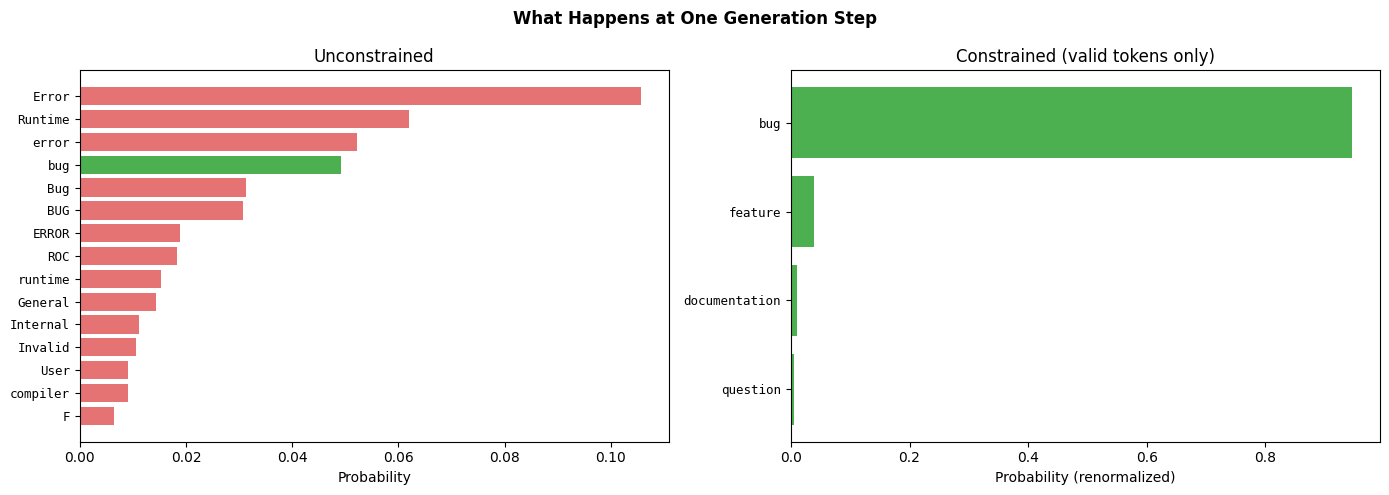

Blocked: 94.8% of probability mass | Vocab: 151,936 → Allowed: 4


In [12]:
from utils import plot_constrained_vs_unconstrained

prompt = 'Parse: [ROCm] torch.compile fails with RuntimeError\n{"issue_type": "'
allowed = ["bug", "feature_request", "documentation", "question"]

plot_constrained_vs_unconstrained(prompt, allowed, model, tokenizer)

## Part 2: Retrieval-Augmented Generation (RAG)

### Background

In Part 1, you focused on the *format* of the model's output. In Part 2, you focus on the *content* — specifically, how to ground the model's answers in real documentation so it doesn't hallucinate.

**Retrieval-Augmented Generation (RAG)** is a technique where you:

1. **Retrieve** relevant passages from a document corpus based on the user's question
2. **Pack** those passages into the prompt as context
3. **Generate** an answer grounded in the retrieved context

This is one of the most widely used patterns in production LLM applications — it lets you add domain-specific knowledge without fine-tuning the model.

In this part, you'll build a RAG pipeline from scratch using real PyTorch documentation as the corpus. You'll implement the full chain: chunking → embedding → retrieval → context packing → grounded generation. Then you'll stress-test the pipeline to see how the context budget affects answer quality.

### Setup

Load a sentence embedding model for retrieval. The embedding model (`all-MiniLM-L6-v2`) converts text into 384-dimensional vectors that capture semantic meaning — similar questions and relevant passages will have similar vectors. The generation model from Part 1 is reused.

In [13]:
from sentence_transformers import SentenceTransformer
from utils import fetch_page, chunk_corpus, Retriever

embedder = SentenceTransformer("all-MiniLM-L6-v2")
print("Embedding model loaded.")

Embedding model loaded.


### Fetch and Explore the Corpus

The corpus is 7 pages from the official PyTorch documentation, covering serialization, modules, optimizers, autograd, distributed training, CUDA, and data loading. Each page is fetched, parsed with BeautifulSoup to extract the main content, and truncated to 15,000 characters.

These are real documentation pages — long, detailed, and full of code examples, API signatures, and cross-references. This makes chunking and retrieval non-trivial.

In [14]:
PYTORCH_URLS = [
    "https://pytorch.org/docs/stable/notes/serialization.html",
    "https://pytorch.org/docs/stable/generated/torch.nn.Module.html",
    "https://pytorch.org/docs/stable/optim.html",
    "https://pytorch.org/docs/stable/autograd.html",
    "https://pytorch.org/docs/stable/distributed.html",
    "https://pytorch.org/docs/stable/notes/cuda.html",
    "https://pytorch.org/docs/stable/data.html",
]

print("Fetching PyTorch docs...")
corpus = [fetch_page(url) for url in PYTORCH_URLS]
corpus = [doc for doc in corpus if doc["content"]]
print(f"Corpus ready: {len(corpus)} documents")
for doc in corpus:
    print(f"  • {doc['title'][:70]}  ({len(doc['content']):,} chars)")

Fetching PyTorch docs...
Corpus ready: 7 documents
  • Serialization semantics — PyTorch 2.11 documentation  (15,000 chars)
  • Module — PyTorch 2.11 documentation  (15,000 chars)
  • torch.optim — PyTorch 2.11 documentation  (15,000 chars)
  • Automatic differentiation package - torch.autograd — PyTorch 2.11 docu  (15,000 chars)
  • Distributed communication package - torch.distributed — PyTorch 2.11 d  (15,000 chars)
  • CUDA semantics — PyTorch 2.11 documentation  (15,000 chars)
  • torch.utils.data — PyTorch 2.11 documentation  (15,000 chars)


In [15]:
def _merge_paragraphs(paragraphs, min_chunk_size, max_chunk_size):
    """Merge paragraphs into right-sized text chunks (provided helper — do not edit)."""
    chunks = []
    current = ""
    for paragraph in paragraphs:
        candidate = current + "\n\n" + paragraph if current else paragraph
        if len(candidate) > max_chunk_size and current:
            chunks.append(current)
            current = paragraph
            while len(current) > max_chunk_size:
                chunks.append(current[:max_chunk_size])
                current = current[max_chunk_size:]
        else:
            current = candidate
    if current:
        if len(current) < min_chunk_size and chunks:
            chunks[-1] += "\n\n" + current
        else:
            chunks.append(current)
    return chunks

### Exercise 3: Chunk Documents for Retrieval

Before you can retrieve relevant passages, you need to split long documents into smaller chunks. This is a critical step — chunk size directly affects retrieval quality:

- **Too large**: Chunks contain mixed topics, diluting relevance scores and wasting context budget
- **Too small**: Chunks lack enough context to be useful on their own
- **Just right**: Each chunk covers a coherent topic and fits within the embedding model's sweet spot

#### Why Chunk on Paragraph Boundaries?

Splitting mid-sentence creates chunks that are hard to understand in isolation. Splitting on double newlines (`\n\n`) gives natural paragraph boundaries, preserving readability. The helper function `_merge_paragraphs` (defined in the cell above) handles the merging loop for you — it walks through paragraphs, joins consecutive ones until the size limit, and flushes oversized content.

#### Your Task

The paragraph splitting is already done for you. Implement `chunk_document` in **2 lines**:

1. **Merge** the paragraphs into right-sized text chunks by calling `_merge_paragraphs(paragraphs, min_chunk_size, max_chunk_size)`
2. **Return** a list of dicts — one per chunk — with keys `"text"`, `"title"`, and `"url"` (carrying the source document's metadata for attribution)

In [16]:
# GRADED CELL: exercise 3

def chunk_document(doc: Dict, min_chunk_size: int = 100, max_chunk_size: int = 600) -> List[Dict]:
    """
    Split a document into chunks that respect paragraph boundaries.

    Args:
        doc: {"title": str, "url": str, "content": str}
        min_chunk_size: don't emit chunks shorter than this (merge into previous)
        max_chunk_size: start a new chunk when merging would exceed this

    Returns:
        List of {"text": str, "title": str, "url": str}
    """
    paragraphs = [p.strip() for p in doc["content"].split("\n\n") if p.strip()] 

    ### START CODE HERE ###
    raw_chunks = _merge_paragraphs(paragraphs, min_chunk_size, max_chunk_size)
    chunks = [
        {
            "text":chunk,
            "title":doc["title"],
            "url":doc["url"]
        }
        for chunk in raw_chunks
    ]
    return chunks
    ### END CODE HERE ###

Run the cell below to build the chunk index and verify your implementation:

In [17]:
from utils import display_chunks_summary
chunks = chunk_corpus(corpus, chunk_fn=chunk_document)
display_chunks_summary(chunks, corpus)

#### Build the Retriever

The `Retriever` class from `utils.py` handles embedding and similarity search. It embeds all chunks on initialization, then for each query, computes cosine similarity against all chunk embeddings and returns the top-k most similar. This is provided for you — no changes needed.

In [18]:
retriever = Retriever(chunks, embedder)

Embedding 196 chunks...


Batches: 100%|██████████| 7/7 [00:00<00:00, 40.54it/s]

Retriever ready.


Test the retriever with a few sample queries to verify it returns relevant chunks:

In [19]:
from utils import display_retrieval_results
test_queries = [
    "How do I save and load model checkpoints?",
    "What optimizers are available in PyTorch?",
    "How does autograd compute gradients?",
]
display_retrieval_results(test_queries, retriever, top_k=3)

#,Score,Source,Preview
1,0.529,Serialization semantics — PyTorch 2.11 docume,"Tensors on certain devices such as XLA are serialized as pickled numpy arrays. As such, their storag..."
2,0.525,Serialization semantics — PyTorch 2.11 docume,Loading a checkpoint with torch.load and filling in the data bytes of tensors later. To inspect t...
3,0.517,Serialization semantics — PyTorch 2.11 docume,"""checkpoint.pt"" ) with FakeTensorMode () as mode : fake_sd = torch . load ( ""checkpoin..."
#,Score,Source,Preview
1,0.565,torch.optim — PyTorch 2.11 documentation,"torch.optim # Created On: Jun 13, 2025 | Last Updated On: Jan 26, 2026 torch.optim is a package ..."
2,0.548,torch.optim — PyTorch 2.11 documentation,Register an optimizer step post hook which will be called after optimizer step. Optimizer.zero_grad...
3,0.525,Distributed communication package - torch.dis,nccl xccl Device CPU GPU CPU GPU CPU GPU CPU GPU send ✓ ✘ ✓ ? ✘ ✓ ✘ ✓ recv ✓ ✘...
#,Score,Source,Preview
1,0.660,Automatic differentiation package - torch.aut,"Automatic differentiation package - torch.autograd # Created On: Dec 23, 2016 | Last Updated On: N..."
2,0.566,Automatic differentiation package - torch.aut,"s keep track of in-place operations applied to them, and if the implementation detects that a tensor..."


In [20]:
def _pack_context(candidates, max_context_chars):
    """Greedily pack chunks within the character budget (provided helper — do not edit)."""
    included = []
    char_count = 0
    for chunk in candidates:
        chunk_len = len(chunk["text"])
        if char_count + chunk_len <= max_context_chars:
            included.append(chunk)
            char_count += chunk_len
        elif not included:
            truncated = {**chunk, "text": chunk["text"][:max_context_chars]}
            included.append(truncated)
            char_count = len(truncated["text"])
    return included, char_count


def _rag_prompt(included, question):
    """Build the grounded RAG prompt from included chunks (provided helper — do not edit)."""
    context = "\n\n---\n\n".join(c["text"] for c in included)
    return f"""Use the following PyTorch documentation to answer the question.
Only use information from the documentation. If the answer is not in the documentation, say "I don't have enough information to answer this from the provided docs."

Documentation:
{context}

Question: {question}"""


def _rag_result(answer, candidates, included, char_count):
    """Build the RAG result dictionary (provided helper — do not edit)."""
    return {
        "answer": answer,
        "chunks_used": len(included),
        "chunks_retrieved": len(candidates),
        "context_chars": char_count,
        "sources": [{"title": c["title"], "url": c["url"], "score": c["score"]} for c in included],
    }

### Exercise 4: Build the RAG Pipeline

Now you'll assemble the full RAG pipeline: retrieve relevant chunks, pack them into a context block within a character budget, build a grounded prompt, and generate an answer.

The heavy lifting — context packing, prompt construction, and result formatting — is handled by three helper functions defined in the cell above (`_pack_context`, `_rag_prompt`, `_rag_result`). Your job is to wire them together.

#### Your Task

Implement `rag_answer` in **3 lines**:

1. **Retrieve** the top-k chunks: `candidates = retriever.search(question, top_k=top_k)`
2. **Pack** chunks within the character budget: `included, char_count = _pack_context(candidates, max_context_chars)`
3. **Generate** the answer: `answer = generate(_rag_prompt(included, question), model, tokenizer)`

In [21]:
# GRADED CELL: exercise 4

def rag_answer(question: str, retriever: Retriever,
               top_k: int = 5, max_context_chars: int = 3000) -> Dict:
    """
    Full RAG pipeline — retrieve, pack context, generate.

    Args:
        question: the user's question
        retriever: the Retriever object from Exercise 3
        top_k: how many chunks to retrieve
        max_context_chars: character budget for the context block

    Returns:
        dict with keys: "answer", "chunks_used", "chunks_retrieved",
                        "context_chars", "sources"
    """
    ### START CODE HERE ###
    candidates = retriever.search(question, top_k=top_k)
    included, char_count = _pack_context(candidates, max_context_chars)
    answer = generate(_rag_prompt(included,question), model, tokenizer)
    ### END CODE HERE ###
    return _rag_result(answer, candidates, included, char_count) 

Run the cell below to compare RAG answers against answers generated without any context. Notice how RAG answers cite specific details from the documentation, while bare answers rely on the model's training data (which may be outdated or incorrect):

In [22]:
QUESTIONS = [
    "How do I save and load model checkpoints in PyTorch?",
    "How do I use DistributedDataParallel for multi-GPU training?",
    "What learning rate schedulers does PyTorch provide?",
]

for q in QUESTIONS:
    bare_answer = generate(f"Answer this PyTorch question concisely:\n\n{q}", model, tokenizer)
    result = rag_answer(q, retriever)

    print("═" * 70)
    print(f"Q: {q}")
    print(f"\n── Without RAG ──")
    print(bare_answer[:300])
    print(f"\n── With RAG ({result['chunks_used']} chunks, {result['context_chars']} chars) ──")
    print(result["answer"][:300])
    print(f"\nSources:")
    for s in result["sources"]:
        print(f"  [{s['score']:.3f}] {s['title'][:60]}")
    print()

══════════════════════════════════════════════════════════════════════
Q: How do I save and load model checkpoints in PyTorch?

── Without RAG ──
To save and load model checkpoints in PyTorch, you can use the `torch.save()` function to save your model's state dictionary or entire model instance, and then use `torch.load()` to load it later. Here is an example of how to do this:

```python
# Save the model
model = YourModelClass()  # Replace w

── With RAG (5 chunks, 2878 chars) ──
To save a model checkpoint in PyTorch, you can use the `torch.save` function. This function takes two arguments: the state dictionary of your model and the path where you want to save the checkpoint. Here's how you would do it:

```python
model = MyModel()  # Assuming MyModel is your custom model cl

Sources:
  [0.685] Serialization semantics — PyTorch 2.11 documentation
  [0.652] Serialization semantics — PyTorch 2.11 documentation
  [0.649] Serialization semantics — PyTorch 2.11 documentation
  [0.605] Seri

### Exercise 5: Stress-Test Your Pipeline

A well-built RAG pipeline needs to handle different context budgets gracefully. In this exercise, you'll test the same question under three conditions to see how context budget affects answer quality:

| Condition | `max_context_chars` | `top_k` | What It Tests |
|-----------|-------------------|---------|--------------| 
| **Tight** | 500 | 5 | Barely any context — does the model still answer correctly with minimal information? |
| **Normal** | 3,000 | 5 | Reasonable budget — the expected operating point for most queries |
| **Flooded** | 15,000 | 20 | Dump everything in — does extra context help or hurt? (This tests "when RAG hurts") |

#### Why This Matters

Too little context means the model lacks information and may hallucinate or give incomplete answers. Too much context introduces noise — irrelevant passages that can distract the model or push important information out of the attention window. Finding the right balance is a key part of context engineering in production RAG systems.

#### Your Task

Implement `stress_test` by filling in the loop body — the conditions list and the loop scaffolding are already provided. Inside the loop, write **2 lines**:

```python
r = rag_answer(question, retriever, top_k=cond["top_k"], max_context_chars=cond["max_context_chars"])
r["label"] = cond["label"]
```

In [23]:
# GRADED CELL: exercise 5

def stress_test(question: str, retriever: Retriever) -> List[Dict]:
    """
    Run the RAG pipeline under three conditions and return results.

    Conditions:
        1. label="tight",   max_context_chars=500,   top_k=5
        2. label="normal",  max_context_chars=3000,  top_k=5
        3. label="flooded", max_context_chars=15000,  top_k=20

    For each condition:
        - Call rag_answer with those parameters
        - Add a "label" key to the result dict

    Returns:
        List of 3 result dicts (one per condition).
    """

    conditions = [ 
        {"label": "tight",   "max_context_chars": 500,   "top_k": 5}, 
        {"label": "normal",  "max_context_chars": 3000,  "top_k": 5}, 
        {"label": "flooded", "max_context_chars": 15000,  "top_k": 20}, 
    ] 

    ### START CODE HERE ### (Block 1: Run rag_answer for each condition)
    results = [] 
    for cond in conditions: # @KEEP
        r = rag_answer(question, retriever, top_k=cond["top_k"], max_context_chars=cond["max_context_chars"])
        r["label"] = cond["label"]
        results.append(r) 
    ### END CODE HERE ###

    return results 

Run the comparison below. Pay attention to how the answers differ across conditions — particularly whether the "flooded" condition actually improves over "normal", or whether the extra context introduces noise:

In [24]:
QUESTION = "How do I save and load model checkpoints in PyTorch?"

results = stress_test(QUESTION, retriever)

print(f"Q: {QUESTION}\n")
print(f"{'Condition':<10} {'Chunks':<10} {'Ctx Chars':<12} {'Answer preview'}")
print("─" * 80)
for r in results:
    preview = r["answer"][:60].replace("\n", " ")
    print(f"{r['label']:<10} {r['chunks_used']:<10} {r['context_chars']:<12} {preview}…")

for r in results:
    print(f"\n{'═' * 70}")
    print(f"{r['label'].upper()} — {r['chunks_used']} chunks, {r['context_chars']} chars")
    print(f"{'═' * 70}")
    print(r["answer"])

Q: How do I save and load model checkpoints in PyTorch?

Condition  Chunks     Ctx Chars    Answer preview
────────────────────────────────────────────────────────────────────────────────
tight      1          500          To save a model checkpoint in PyTorch, you can use the `torc…
normal     5          2878         To save a model checkpoint in PyTorch, you can use the `torc…
flooded    20         11174        To save and load model checkpoints in PyTorch, you can use t…

══════════════════════════════════════════════════════════════════════
TIGHT — 1 chunks, 500 chars
══════════════════════════════════════════════════════════════════════
To save a model checkpoint in PyTorch, you can use the `torch.save` function. This function takes two arguments: the first is the model instance that you want to save, and the second is an optional dictionary where you can specify additional information about the model (like its state_dict).

Here's how you would typically save a model:

```python


**Congratulations on finishing this graded lab!** If everything is running correctly, you can go ahead and submit your code for grading.